# Stage Routing in a Square Room

This notebook demonstrates three routing variants in the same $10 \times 10$ room:

- Scenario 1: `distribution -> waiting stage -> stage -> exit`
- Scenario 2: `distribution -> waiting stage -> exit`
- Scenario 3: `distribution -> exit`

The scenario is loaded from [`scenario_files/stage-routing-square-room`](scenario_files/stage-routing-square-room).

In [1]:
import logging
from datetime import datetime

# Silence jupedsim-scenarios' INFO/DEBUG output. See the howto
# "How do I inspect a scenario?" for the full list of levels.
logging.getLogger("jupedsim_scenarios").setLevel(logging.WARNING)

print(f"Executed on {datetime.now().strftime('%d.%m.%Y, %H:%M')}")

from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pedpy

from jupedsim_scenarios import load_scenario, run_scenario, run_sweep

Executed on 25.05.2026, 14:13


In [2]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fafafa",
        "axes.edgecolor": "#444444",
        "axes.labelcolor": "#222222",
        "axes.titleweight": "bold",
        "xtick.color": "#222222",
        "ytick.color": "#222222",
        "font.size": 11,
    }
)

COLORS = {
    "scenario_1": "#4C72B0",
    "scenario_2": "#DD8452",
    "scenario_3": "#55A868",
}

LABELS = {
    "scenario_1": "Wait 5 s at stage 1, then visit stage 2",
    "scenario_2": "Wait 5 s at stage 1, then go to exit",
    "scenario_3": "Directly go to exit",
}


## Load the Base Scenario

The scenario directory already contains the room geometry, the start distribution, the exit, and both stages. We then clone the loaded scenario data before changing the journey definitions so each routing variant stays independent.

In [3]:
SCENARIO_DIR = Path("scenario_files") / "stage-routing-square-room"
base_scenario = load_scenario(str(SCENARIO_DIR))
print(base_scenario.summary())

Scenario: /Users/chraibi/workspace/PedestrianDynamics/jupedsim-scenarios/examples/cookbook/scenario_files/stage-routing-square-room
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      80s
  Exits:         1
  Distributions: 1
  Stages:        2
  Zones:         0
  Journeys:      1
  Agents:        ~10
  Journey elems: 4
  Route:         1 distribution, 2 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-checkpoints_0 -> jps-checkpoints_1 -> jps-exits_0
    jps-distributions_0: 10 agents


In [ ]:
def make_variant(base, name: str, stages: list[str]):
    variant = base.copy()
    variant.source_path = name
    variant.raw["journeys"] = [
        {
            "id": "jps-journeys_0",
            "stages": ["jps-distributions_0", *stages, "jps-exits_0"],
        }
    ]
    return variant


def add_room_markers(ax):
    overlays = [
        (patches.Rectangle((3.2, -0.9), 1.6, 1.8, facecolor="#CFE8FF", edgecolor="#4C72B0", linewidth=1.5), "Start", (4.0, 1.15)),
        (patches.Rectangle((-4.35, -0.85), 0.7, 1.7, facecolor="#D6F5D6", edgecolor="#55A868", linewidth=1.5), "Exit", (-4.0, 1.15)),
        (patches.Rectangle((-0.55, 3.45), 1.1, 1.1, facecolor="#FCE3C1", edgecolor="#DD8452", linewidth=1.5), "Stage 1\n(wait 5 s)", (0.0, 4.95)),
        (patches.Rectangle((-0.55, -4.55), 1.1, 1.1, facecolor="#E7D9F7", edgecolor="#8172B2", linewidth=1.5), "Stage 2", (0.0, -3.05)),
    ]
    for patch, text, label_xy in overlays:
        ax.add_patch(patch)
        ax.text(label_xy[0], label_xy[1], text, ha="center", va="center", fontsize=10, weight="bold")
    ax.set_xlim(-5.4, 5.4)
    ax.set_ylim(-5.4, 5.4)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(color="#d0d0d0", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


In [5]:
SCENARIOS = {
    "scenario_1": make_variant(base_scenario, "scenario_1", ["jps-checkpoints_0", "jps-checkpoints_1"]),
    "scenario_2": make_variant(base_scenario, "scenario_2", ["jps-checkpoints_0"]),
    "scenario_3": make_variant(base_scenario, "scenario_3", []),
}

for name, scenario in SCENARIOS.items():
    print(name)
    print(scenario.summary())
    print("=====================================================")

scenario_1
Scenario: scenario_1
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      80s
  Exits:         1
  Distributions: 1
  Stages:        2
  Zones:         0
  Journeys:      1
  Agents:        ~10
  Journey elems: 4
  Route:         1 distribution, 2 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-checkpoints_0 -> jps-checkpoints_1 -> jps-exits_0
    jps-distributions_0: 10 agents
scenario_2
Scenario: scenario_2
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      80s
  Exits:         1
  Distributions: 1
  Stages:        2
  Zones:         0
  Journeys:      1
  Agents:        ~10
  Journey elems: 3
  Route:         1 distribution, 1 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-checkpoints_0 -> jps-exits_0
    jps-distributions_0: 10 agents
scenario_3
Scenario: scenario_3
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      80s
  Exits:         1
  Distributions: 1
  Sta

## Run the Three Variants

For each scenario we keep one deterministic run for the trajectory plot and run a seed sweep for the evacuation-time histogram.

In [6]:
%%capture
def run_variant(scenario, demo_seed=42, seeds=range(40, 55)):
    print("=================================================")
    demo_result = run_scenario(scenario, seed=demo_seed)
    demo_df = demo_result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy()
    demo_traj = pedpy.TrajectoryData(demo_df, frame_rate=demo_result.frame_rate)
    demo_metrics = dict(demo_result.metrics)
    demo_result.cleanup()

    sweep = run_sweep(scenario, seeds=list(seeds), workers=4)
    evac_times = sweep.to_dataframe()["evacuation_time"].to_numpy()
    sweep.cleanup()

    return {
        "demo_seed": demo_seed,
        "demo_traj": demo_traj,
        "demo_metrics": demo_metrics,
        "evac_times": evac_times.astype(float),
    }


results = {name: run_variant(scenario) for name, scenario in SCENARIOS.items()}
walkable_area = pedpy.WalkableArea(base_scenario.walkable_polygon)

summary_rows = []
for name, result in results.items():
    evac_times = result["evac_times"]
    summary_rows.append(
        {
            "scenario": name,
            "routing": LABELS[name],
            "demo evacuation time [s]": result["demo_metrics"]["evacuation_time"],
            "mean evacuation time [s]": evac_times.mean(),
            "std [s]": evac_times.std(ddof=0),
        }
    )

summary_rows

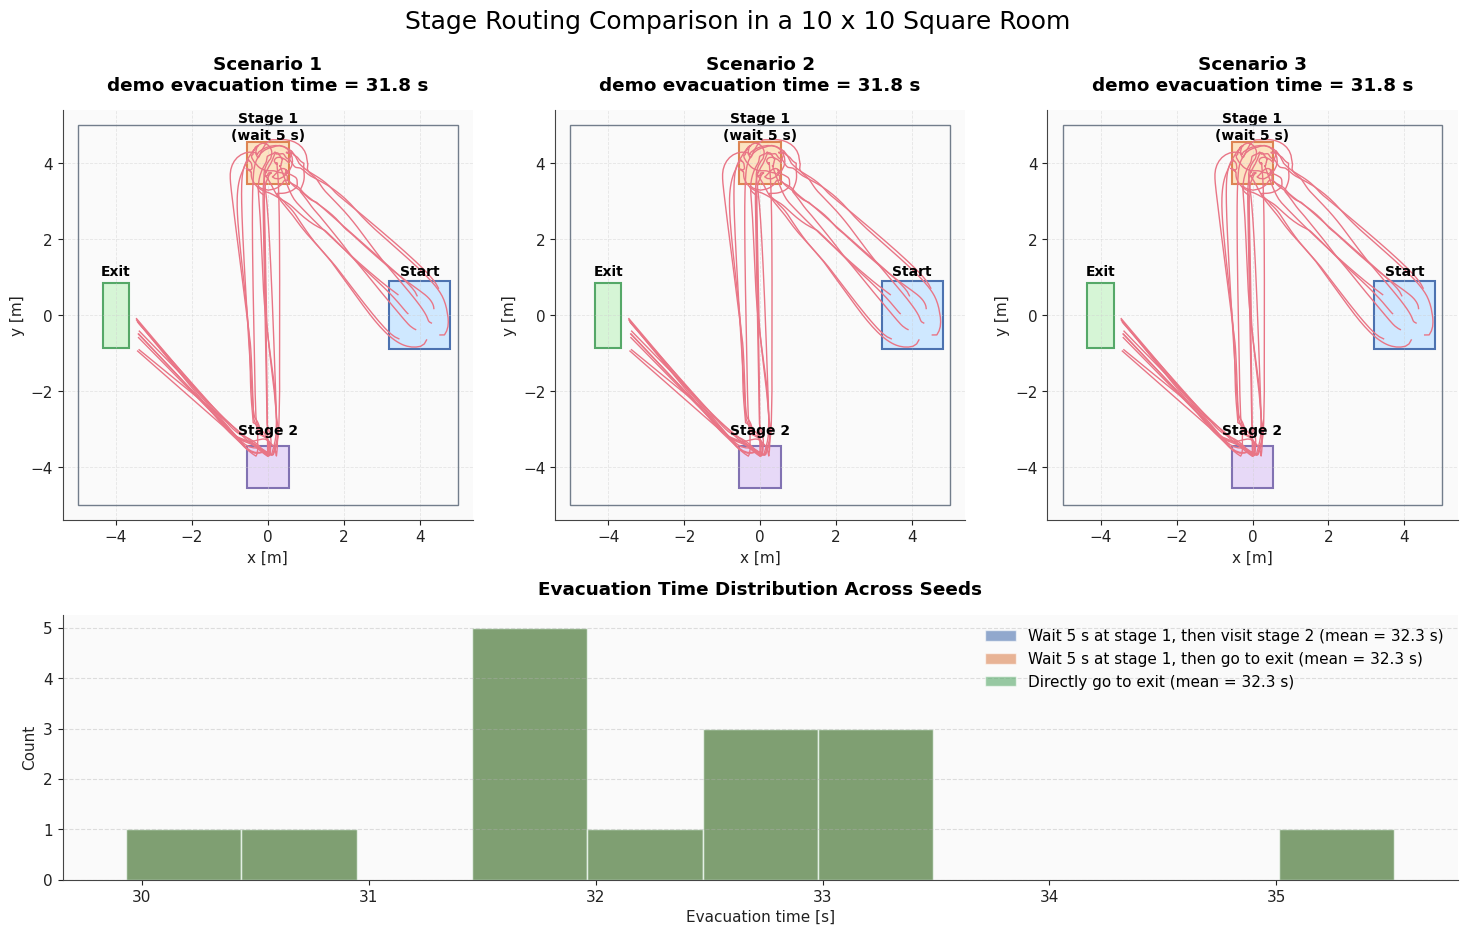

In [7]:
fig = plt.figure(figsize=(18, 10))
grid = fig.add_gridspec(2, 3, height_ratios=[1.4, 0.9], hspace=0.28)

for col, name in enumerate(["scenario_1", "scenario_2", "scenario_3"]):
    ax = fig.add_subplot(grid[0, col])
    pedpy.plot_trajectories(
        traj=results[name]["demo_traj"],
        walkable_area=walkable_area,
        axes=ax,
        alpha=0.75,
        linewidth=0.8,
        color=COLORS[name],
    ).set_aspect("equal")
    add_room_markers(ax)
    ax.set_title(
        f"{name.replace('_', ' ').title()}\n"
        f"demo evacuation time = {results[name]['demo_metrics']['evacuation_time']:.1f} s",
        pad=14,
    )

hist_ax = fig.add_subplot(grid[1, :])
bins = np.linspace(
    min(result["evac_times"].min() for result in results.values()) - 0.5,
    max(result["evac_times"].max() for result in results.values()) + 0.5,
    12,
)

for name in ["scenario_1", "scenario_2", "scenario_3"]:
    evac_times = results[name]["evac_times"]
    hist_ax.hist(
        evac_times,
        bins=bins,
        color=COLORS[name],
        alpha=0.6,
        edgecolor="white",
        linewidth=1.0,
        label=f"{LABELS[name]} (mean = {evac_times.mean():.1f} s)",
    )

hist_ax.set_title("Evacuation Time Distribution Across Seeds", pad=15)
hist_ax.set_xlabel("Evacuation time [s]")
hist_ax.set_ylabel("Count")
hist_ax.grid(axis="y", linestyle="--", alpha=0.4)
hist_ax.spines["top"].set_visible(False)
hist_ax.spines["right"].set_visible(False)
hist_ax.legend(frameon=False, ncol=1, loc="upper right")

fig.suptitle("Stage Routing Comparison in a 10 x 10 Square Room", fontsize=18, y=0.98)
plt.show()